In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os

from sklearn.svm              import SVC
from sklearn.ensemble         import RandomForestClassifier
from sklearn.preprocessing    import StandardScaler, LabelEncoder, label_binarize
from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics          import classification_report, ConfusionMatrixDisplay, roc_auc_score
from sklearn.pipeline         import Pipeline
import xgboost as xgb

os.makedirs('../models', exist_ok=True)
os.makedirs('../plots',  exist_ok=True)

SEED   = 42
COLORS = {'Happy':'gold','Sad':'steelblue','Angry':'crimson',
          'Relaxed':'mediumseagreen','Energetic':'orange'}

In [2]:
df = pd.read_csv('../data/features.csv')
meta_cols = ['filename','genre','mood']
feat_cols = [c for c in df.columns if c not in meta_cols]

X  = df[feat_cols].values.astype(np.float32)
le = LabelEncoder()
y  = le.fit_transform(df['mood'])

print(f"Features : {X.shape[1]}")
print(f"Samples  : {X.shape[0]}")
print(f"Classes  : {list(le.classes_)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

# Scale — fit on TRAIN only to prevent data leakage
scaler  = StandardScaler()
X_tr    = scaler.fit_transform(X_train)
X_te    = scaler.transform(X_test)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")

Features : 52
Samples  : 999
Classes  : ['Angry', 'Energetic', 'Happy', 'Relaxed', 'Sad']

Train: 799 | Test: 200


In [3]:
pipe = Pipeline([('svm', SVC(kernel='rbf', probability=True, random_state=SEED))])
param_grid = {'svm__C': [0.1, 1, 10, 100], 'svm__gamma': ['scale','auto',0.001,0.01]}

print("Running GridSearchCV for SVM (may take 2-3 min)...")
gs = GridSearchCV(pipe, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1)
gs.fit(X_tr, y_train)
svm_best = gs.best_estimator_

print(f"\nBest params : {gs.best_params_}")
print(f"CV F1-macro : {gs.best_score_:.3f}")
print(f"\nTest Report:\n{classification_report(y_test, svm_best.predict(X_te), target_names=le.classes_)}")

Running GridSearchCV for SVM (may take 2-3 min)...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best params : {'svm__C': 100, 'svm__gamma': 'scale'}
CV F1-macro : 0.797

Test Report:
              precision    recall  f1-score   support

       Angry       0.80      0.60      0.69        20
   Energetic       0.62      0.65      0.63        40
       Happy       0.83      0.87      0.85        60
     Relaxed       0.92      0.90      0.91        40
         Sad       0.83      0.85      0.84        40

    accuracy                           0.80       200
   macro avg       0.80      0.77      0.78       200
weighted avg       0.80      0.80      0.80       200



CV F1-macro : 0.770 ± 0.048

Test Report:
              precision    recall  f1-score   support

       Angry       0.89      0.80      0.84        20
   Energetic       0.59      0.50      0.54        40
       Happy       0.74      0.80      0.77        60
     Relaxed       0.90      0.90      0.90        40
         Sad       0.74      0.80      0.77        40

    accuracy                           0.76       200
   macro avg       0.77      0.76      0.76       200
weighted avg       0.76      0.76      0.76       200



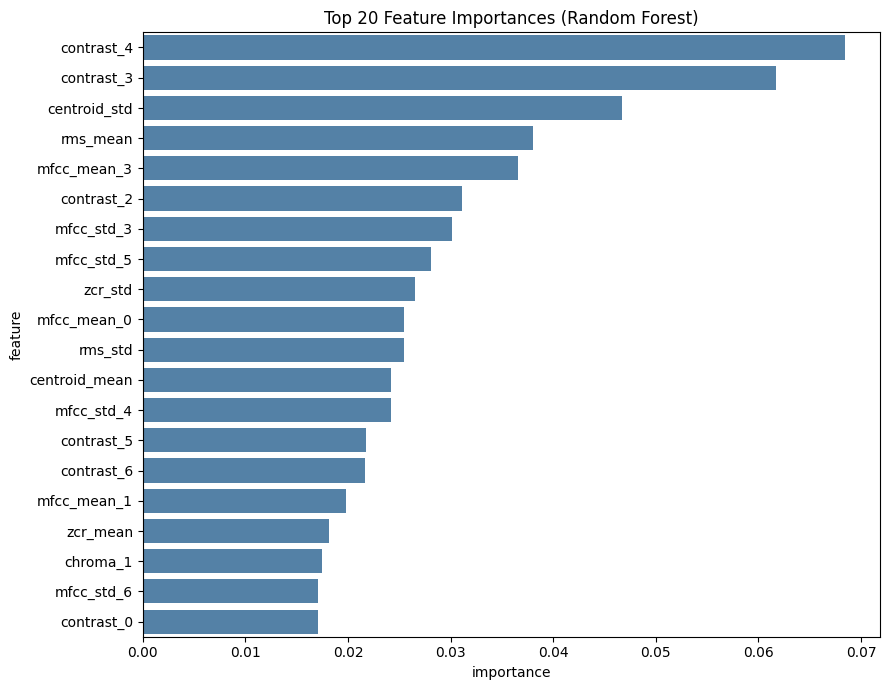

In [4]:
rf = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED)
rf_scores = cross_val_score(rf, X_tr, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
rf.fit(X_tr, y_train)

print(f"CV F1-macro : {rf_scores.mean():.3f} ± {rf_scores.std():.3f}")
print(f"\nTest Report:\n{classification_report(y_test, rf.predict(X_te), target_names=le.classes_)}")

# Feature importance
imp_df = pd.DataFrame({'feature': feat_cols, 'importance': rf.feature_importances_})
imp_df = imp_df.sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(data=imp_df, x='importance', y='feature', color='steelblue', ax=ax)
ax.set_title('Top 20 Feature Importances (Random Forest)')
plt.tight_layout()
plt.savefig('../plots/model_rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
xgb_clf = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=SEED, n_jobs=-1
)
xgb_scores = cross_val_score(xgb_clf, X_tr, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
xgb_clf.fit(X_tr, y_train, eval_set=[(X_te, y_test)], verbose=False)

print(f"CV F1-macro : {xgb_scores.mean():.3f} ± {xgb_scores.std():.3f}")
print(f"\nTest Report:\n{classification_report(y_test, xgb_clf.predict(X_te), target_names=le.classes_)}")

# AUC
y_bin   = label_binarize(y_test, classes=list(range(len(le.classes_))))
y_proba = xgb_clf.predict_proba(X_te)
auc     = roc_auc_score(y_bin, y_proba, multi_class='ovr', average='macro')
print(f"Macro AUC : {auc:.3f}")

d:\moodclassification\venv\lib\site-packages\xgboost\training.py:200: UserWarning: [23:30:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


CV F1-macro : 0.790 ± 0.031

Test Report:
              precision    recall  f1-score   support

       Angry       0.89      0.85      0.87        20
   Energetic       0.66      0.57      0.61        40
       Happy       0.78      0.83      0.81        60
     Relaxed       0.95      0.90      0.92        40
         Sad       0.77      0.85      0.81        40

    accuracy                           0.80       200
   macro avg       0.81      0.80      0.80       200
weighted avg       0.80      0.80      0.80       200

Macro AUC : 0.961


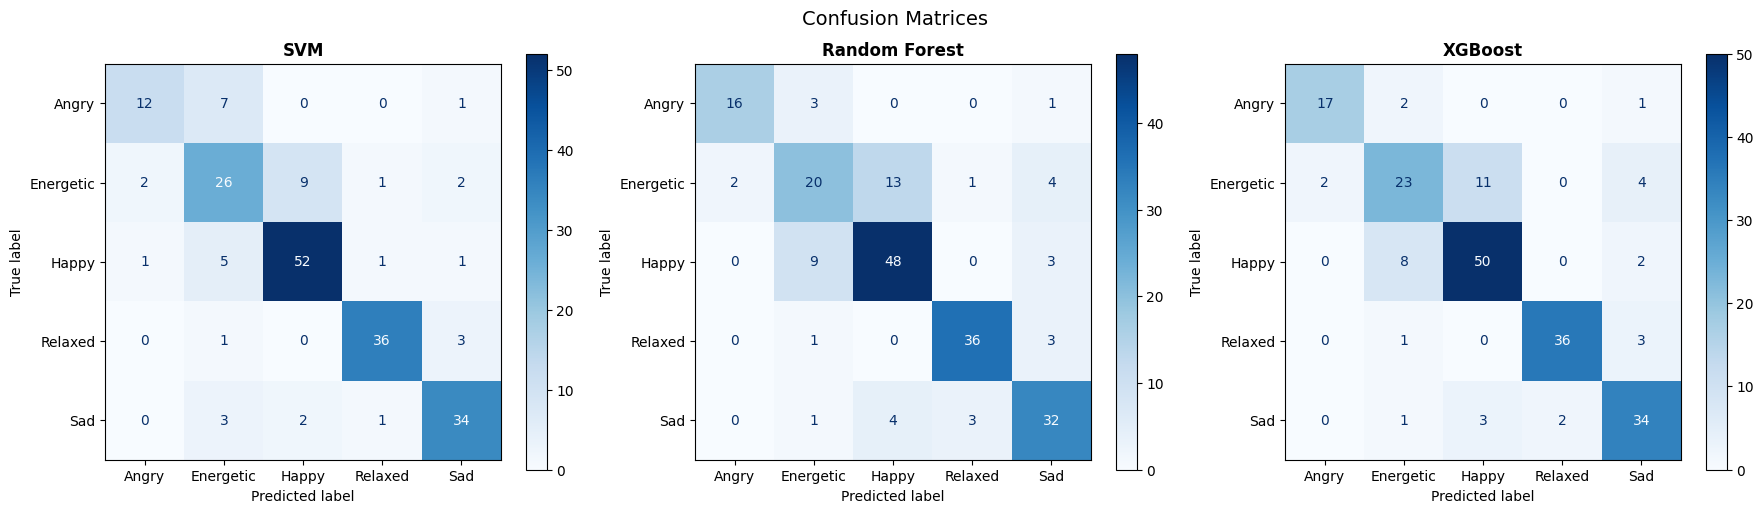


Look for which moods get confused most — that's your key EDA insight.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (model, name) in zip(axes, [(svm_best,'SVM'),(rf,'Random Forest'),(xgb_clf,'XGBoost')]):
    ConfusionMatrixDisplay.from_estimator(
        model, X_te, y_test,
        display_labels=le.classes_,
        cmap='Blues', ax=ax
    )
    ax.set_title(name, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/model_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nLook for which moods get confused most — that's your key EDA insight.")

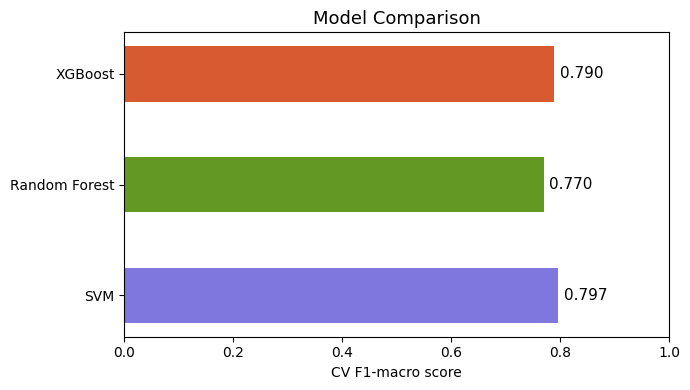


🏆 Best model: SVM (CV F1 = 0.797)


In [7]:
results = {
    'SVM':           gs.best_score_,
    'Random Forest': rf_scores.mean(),
    'XGBoost':       xgb_scores.mean(),
}

fig, ax = plt.subplots(figsize=(7, 4))
names  = list(results.keys())
scores = list(results.values())
bars   = ax.barh(names, scores, color=['#7F77DD','#639922','#D85A30'], height=0.5)
ax.set_xlim(0, 1)
ax.set_xlabel('CV F1-macro score')
ax.set_title('Model Comparison', fontsize=13)
for bar, score in zip(bars, scores):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{score:.3f}', va='center', fontsize=11)
plt.tight_layout()
plt.savefig('../plots/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_name  = max(results, key=results.get)
print(f"\n🏆 Best model: {best_name} (CV F1 = {results[best_name]:.3f})")

In [8]:
model_map = {'SVM': svm_best, 'Random Forest': rf, 'XGBoost': xgb_clf}
best_model = model_map[best_name]

joblib.dump(best_model, '../models/model.pkl')
joblib.dump(scaler,     '../models/scaler.pkl')
joblib.dump(le,         '../models/encoder.pkl')

print(f"✅ Saved {best_name} to models/")
print("   models/model.pkl")
print("   models/scaler.pkl")
print("   models/encoder.pkl")
print("\nNow run: streamlit run app.py")

✅ Saved SVM to models/
   models/model.pkl
   models/scaler.pkl
   models/encoder.pkl

Now run: streamlit run app.py
